In [10]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

import numpy as np
import pandas as pd
from forward_model import read_cosmo_params
from utils import sigma8_difference
from astropy.io import fits
import matplotlib.pyplot as plt

In [4]:
redshift_distribution = fits.open('../data_utils/nz_shapepipe_v1.4.5.fits')

In [8]:
data = redshift_distribution[1].data

In [13]:
data

FITS_rec([( 36.8247217 , -4.276169  , 0.34540001, 4, 24.70260048, 23.60140038, 22.68090057, 22.25709915, -99., 21.91869926, 'VVDS02_DEEP', 387.21816594),
          ( 30.4726645 , -5.3141536 , 0.61909997, 3, 25.90859985, 24.61860085, 23.0095005 , 21.90609932, -99., 21.69910049, 'VIPERS_W1',  42.86563677),
          (214.15185393, 52.29757469, 0.39385623, 4, 25.47940063, 25.14620018, 24.40480042, 24.31500053, -99., 24.83169937, 'DEEP2', 148.04005044),
          ...,
          ( 32.4244245 , -5.1284419 , 0.1409    , 4, 21.37669945, 19.66449928, 18.8029995 , 18.35169983, -99., 18.07489967, 'VIPERS_W1', 853.50651185),
          ( 33.6823633 , -4.776875  , 0.88319999, 4, 26.16659927, 24.19039917, 22.31139946, 21.00279999, -99., 20.36540031, 'VIPERS_W1',  49.25435396),
          (333.509273  ,  0.0535873 , 1.10940003, 3, 23.37879944, 23.21680069, 22.94009972, 22.52099991, -99., 22.25659943, 'VVDS22_WIDE', 109.78685483)],
         dtype=(numpy.record, [('RA', '>f8'), ('Dec', '>f8'), ('Z', '>f8

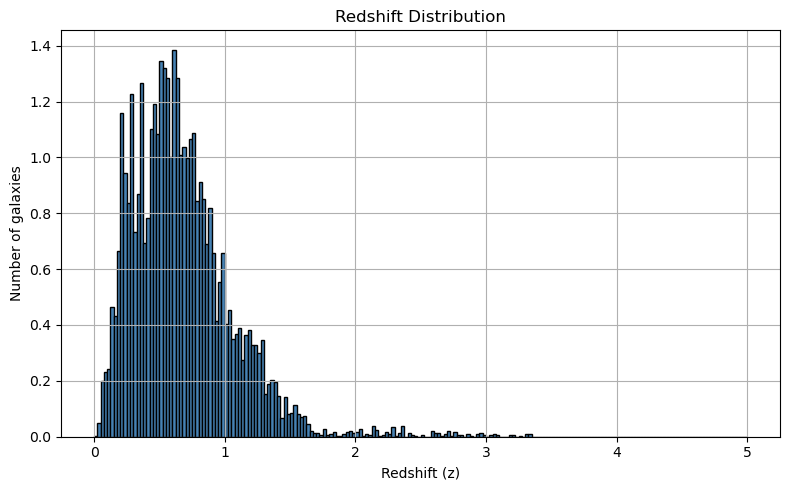

In [15]:
z = data['Z']

# Optional: filter out any non-physical or NaN values
z = z[np.isfinite(z) & (z > 0)]

# Plot the histogram
plt.figure(figsize=(8, 5))
(n, bins, _) = plt.hist(z, bins=200, range=(0, 5.0), color='steelblue', edgecolor='black', density=True, weights=data['som_weight'])
plt.xlabel('Redshift (z)')
plt.ylabel('Number of galaxies')
plt.title('Redshift Distribution')
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
np.savetxt('../data_utils/nz_shapepipe_v1.4.5.txt', np.column_stack((bins[:-1], n)))

In [2]:
path_info = '/lustre/fsmisc/dataset/GowerStreetSims/PKDGRAV3_on_DiRAC_DES_330 - Sheet1.csv'

sim_number = 1

In [3]:
read_cosmo_params(path_info, sim_number)

/lustre/fswork/projects/rech/prk/uid35yw/UNIONS_forward_model/utils.py:150: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(sigma8_difference, args=(cosmo_params,), bounds=[np.log(1e-9), np.log(1.9e-8)], tol=1e-10)


{'h': array([0.66736206]), 'Omega_m': array([0.29004048]), 'Omega_b': array([0.05021784]), 'sigma_8': array([0.7657514]), 'n_s': array([0.94965154]), 'w': array([-1.00894147]), 'm_nu': array([0.06])}
As: 3.079217826322939e-09
sigma8 predicted: [0.90177599]
{'h': array([0.66736206]), 'Omega_m': array([0.29004048]), 'Omega_b': array([0.05021784]), 'sigma_8': array([0.7657514]), 'n_s': array([0.94965154]), 'w': array([-1.00894147]), 'm_nu': array([0.06])}
As: 6.17039815682313e-09
sigma8 predicted: [1.27654185]
{'h': array([0.66736206]), 'Omega_m': array([0.29004048]), 'Omega_b': array([0.05021784]), 'sigma_8': array([0.7657514]), 'n_s': array([0.94965154]), 'w': array([-1.00894147]), 'm_nu': array([0.06])}
As: 2.003884916511912e-09
sigma8 predicted: [0.7274696]
{'h': array([0.66736206]), 'Omega_m': array([0.29004048]), 'Omega_b': array([0.05021784]), 'sigma_8': array([0.7657514]), 'n_s': array([0.94965154]), 'w': array([-1.00894147]), 'm_nu': array([0.06])}
As: [1.6475954e-09]
sigma8 pred

{'h': array([0.66736206]),
 'Omega_m': array([0.29004048]),
 'Omega_b': array([0.05021784]),
 'sigma_8': array([0.7657514]),
 'n_s': array([0.94965154]),
 'w': array([-1.00894147]),
 'm_nu': array([0.06]),
 'A_s': array([2.22033584e-09])}

In [16]:
info = pd.read_csv(path_info, header=1)
cosmo_params = {}
line =  info.loc[info["Serial Number"]==sim_number]
cosmo_params["h"] = line["little_h"].values
cosmo_params["Omega_m"] = line["Omega_m"].values
cosmo_params["Omega_b"] = line["Omega_b"].values
cosmo_params["sigma_8"] = line["sigma_8"].values
cosmo_params["n_s"] = line["n_s"].values
cosmo_params["w"] = line["w"].values
cosmo_params["m_nu"] = line["m_nu"].values

sigma8_difference(np.log(1.01e-8), cosmo_params)

{'h': array([0.73060521]), 'Omega_m': array([0.16547368]), 'Omega_b': array([0.04193141]), 'sigma_8': array([1.12678143]), 'n_s': array([0.96472263]), 'w': array([-0.95505467]), 'm_nu': array([0.1147738])}
As: 1.009999999999999e-08
sigma8 predicted: [1.10568995]


array([0.02109149])